# DADB effects on matter perturbations in $\Lambda$CDM and GEDF

This notebook compares three CLASS calculations with identical primordial and present-day standard-sector parameters:

1. pure $\Lambda$CDM (`f_gedf = f_gedf_2 = 0`, DADB disabled);
2. $\Lambda$CDM + DADB with the default late-time DADB parameters;
3. GEDF + DADB with `f_gedf = 0.1` and the GEDF settings from `260810_dadb.ipynb`.

The requested modes are in CLASS units of $\mathrm{Mpc}^{-1}$. The stored perturbations are explicitly retained in synchronous gauge. In a DADB calculation, `omega_cdm` is the total present-day CDM density and CLASS splits it into uncoupled and coupled populations. Therefore the total synchronous-gauge DM contrast plotted here is

$$\delta_c = \frac{\rho_u\delta_u+\rho_d\delta_d}{\rho_u+\rho_d}.$$

The DADB perturbation closure used below is `drag_only`; the optional phenomenological fifth force is not enabled.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
K_MODES = np.array([0.003, 0.01, 0.03, 0.1, 0.3])  # 1/Mpc
K_OUTPUT = ",".join(f"{k:g}" for k in K_MODES)
K_MODES

array([0.003, 0.01 , 0.03 , 0.1  , 0.3  ])

## Model definitions

A fixed `H0` is used so every comparison is made at the same physical wavenumber and present expansion rate. The DADB and GEDF parameters follow `260810_dadb.ipynb`.

In [2]:
common = {
    'ln10^{10}A_s': 3.05,
    'n_s': 0.973,
    'H0': 67,
    'omega_b': 0.02233,
    'omega_cdm': 0.1204,  # total present-day CDM, including the DADB split
    'tau_reio': 0.054,
    'f_gedf_2': 0.0,
    'gauge': 'synchronous',
    'get_perturbations_in_current_gauge': 'yes',
    'k_output_values': K_OUTPUT,
    'output': 'mPk',
    'P_k_max_1/Mpc': 3.0,
    'z_max_pk': 10.0,
    'a_ini_over_a_today_default': 1e-16,
    'start_small_k_at_tau_c_over_tau_h': 0.000004,
}

gedf_defaults = {
    'ac_gedf': 1.0 / 2500.0,
    's_a_gedf': 3.0,
    'wi_edf': -1.0,
    'wf_edf': 1.0,
    'Theta_i_edf': np.pi - 1.0,
    'has_gedf_perturbations': 'yes',
}

dadb_defaults = {
    'dadb_like': 'yes',
    'dadb_F_d': 0.30,
    'dadb_Delta_e': 0.0,
    'dadb_z_e': 3500.0,
    'dadb_p_e': 6.0,
    'dadb_Delta_l': 0.080,
    'dadb_z_l': 0.43,
    'dadb_p_l': 6.0,
    'dadb_epsilon_X': 0.25,
    'dadb_z_X': 0.08,
    'dadb_p_X': 20.0,
    'dadb_perturbation_mode': 'drag_only',
    'dadb_beta5': 0.50,
    'dadb_kC_hmpc': 0.05,
}

pure_params = {**common, **gedf_defaults, 'f_gedf': 0.0, 'dadb_like': 'no'}
lcdm_dadb_params = {**common, **gedf_defaults, **dadb_defaults, 'f_gedf': 0.0}
gedf_dadb_params = {**common, **gedf_defaults, **dadb_defaults, 'f_gedf': 0.1}

In [3]:
def compute_class(parameters):
    model = Class()
    model.set(parameters)
    model.compute()
    return model

pure_lcdm = compute_class(pure_params)
lcdm_dadb = compute_class(lcdm_dadb_params)
gedf_dadb = compute_class(gedf_dadb_params)

print('All three CLASS models computed successfully.')

CosmoSevereError: 

Error in Class: Class did not read input parameter(s): f_gedf_2, ac_gedf, s_a_gedf, wi_edf, wf_edf


## Construct the total CDM density contrast

The pure model has only `delta_cdm`. For DADB models, `delta_cdm` is the uncoupled population and `delta_dadb` is the coupled population. Background density weights are interpolated onto each perturbation time grid before combining them. All model curves are then interpolated in $\ln a$ onto a common grid before taking ratios.

In [11]:
def scalar_modes(model):
    modes = model.get_perturbations()['scalar']
    if len(modes) != len(K_MODES):
        raise RuntimeError(f'Expected {len(K_MODES)} scalar modes, got {len(modes)}')
    return modes

def total_cdm_on_native_grid(model, mode, has_dadb):
    a = np.asarray(mode['a'])
    delta_u = np.asarray(mode['delta_cdm'])
    if not has_dadb:
        return a, delta_u

    bg = model.get_background()
    a_bg = 1.0 / (1.0 + np.asarray(bg['z']))
    rho_u = np.interp(a, a_bg, np.asarray(bg['(.)rho_dadb_u']))
    rho_d = np.interp(a, a_bg, np.asarray(bg['(.)rho_dadb_d']))
    delta_d = np.asarray(mode['delta_dadb'])
    delta_total = (rho_u * delta_u + rho_d * delta_d) / (rho_u + rho_d)
    return a, delta_total

pure_modes = scalar_modes(pure_lcdm)
lcdm_dadb_modes = scalar_modes(lcdm_dadb)
gedf_dadb_modes = scalar_modes(gedf_dadb)

native_sets = []
for i in range(len(K_MODES)):
    native_sets.append((
        total_cdm_on_native_grid(pure_lcdm, pure_modes[i], False),
        total_cdm_on_native_grid(lcdm_dadb, lcdm_dadb_modes[i], True),
        total_cdm_on_native_grid(gedf_dadb, gedf_dadb_modes[i], True),
    ))

a_min = max(item[j][0][0] for item in native_sets for j in range(3))
a_common = np.geomspace(a_min, 1.0, 800)
z_common = 1.0 / a_common - 1.0

def interpolate_delta(native):
    a, delta = native
    return np.interp(np.log(a_common), np.log(a), delta)

delta_pure = np.array([interpolate_delta(item[0]) for item in native_sets])
delta_lcdm_dadb = np.array([interpolate_delta(item[1]) for item in native_sets])
delta_gedf_dadb = np.array([interpolate_delta(item[2]) for item in native_sets])
relative_lcdm_dadb = delta_lcdm_dadb / delta_pure - 1.0
relative_gedf_dadb = delta_gedf_dadb / delta_pure - 1.0

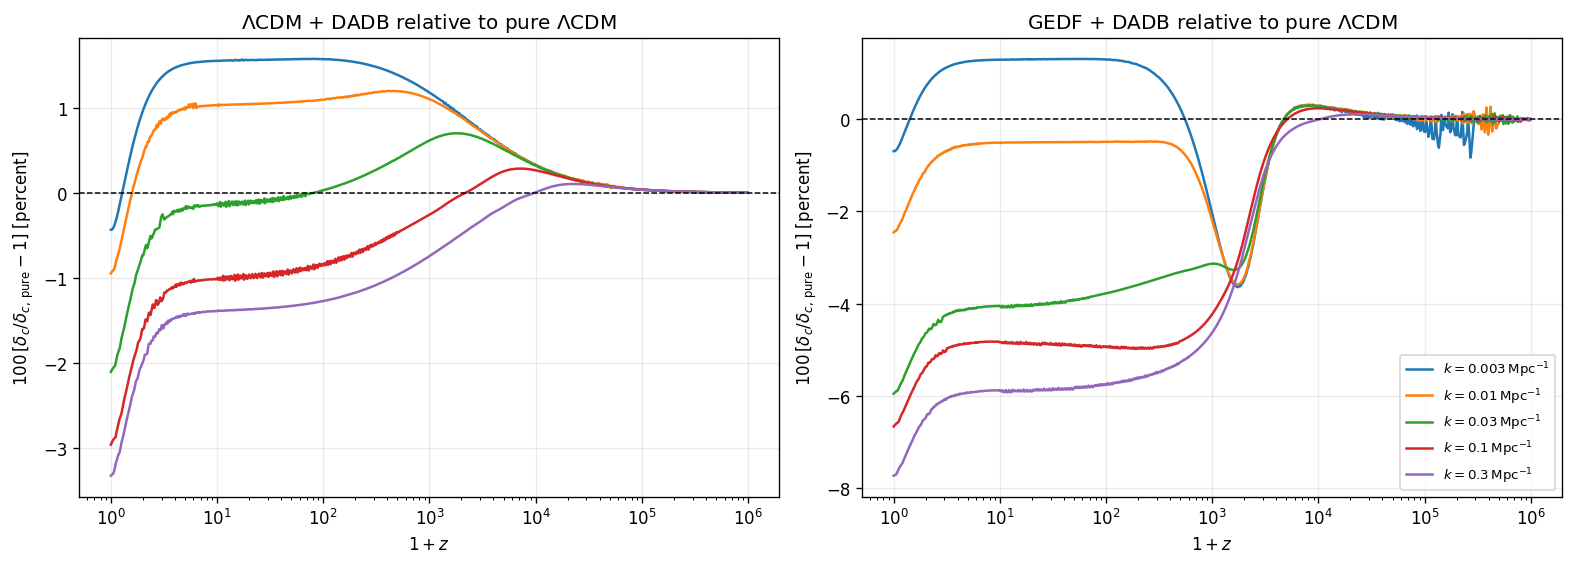

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True, constrained_layout=True)
plot_mask = z_common <= 1.0e6  # includes GEDF transition; omits noisy ratios of tiny superhorizon amplitudes
comparisons = [
    (relative_lcdm_dadb, r'$\Lambda$CDM + DADB relative to pure $\Lambda$CDM'),
    (relative_gedf_dadb, r'GEDF + DADB relative to pure $\Lambda$CDM'),
]
for ax, (relative, title) in zip(axes, comparisons):
    for i, k in enumerate(K_MODES):
        ax.plot(1.0 + z_common[plot_mask], 100.0 * relative[i, plot_mask], label=fr'$k={k:g}\,\mathrm{{Mpc}}^{{-1}}$')
    ax.axhline(0.0, color='k', lw=0.9, ls='--')
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.set_xlabel(r'$1+z$')
    ax.set_ylabel(r'$100\,[\delta_c/\delta_{c,\,\mathrm{pure}}-1]$ [percent]')
    ax.set_title(title)
axes[1].legend(fontsize=8, ncol=1)
plt.show()

## Linear matter power spectrum at $z=0$

The ratios below use the same physical $k$ in each model. Since `H0` is fixed, the upper axis can equivalently be read after a common conversion to $h\,\mathrm{Mpc}^{-1}$.

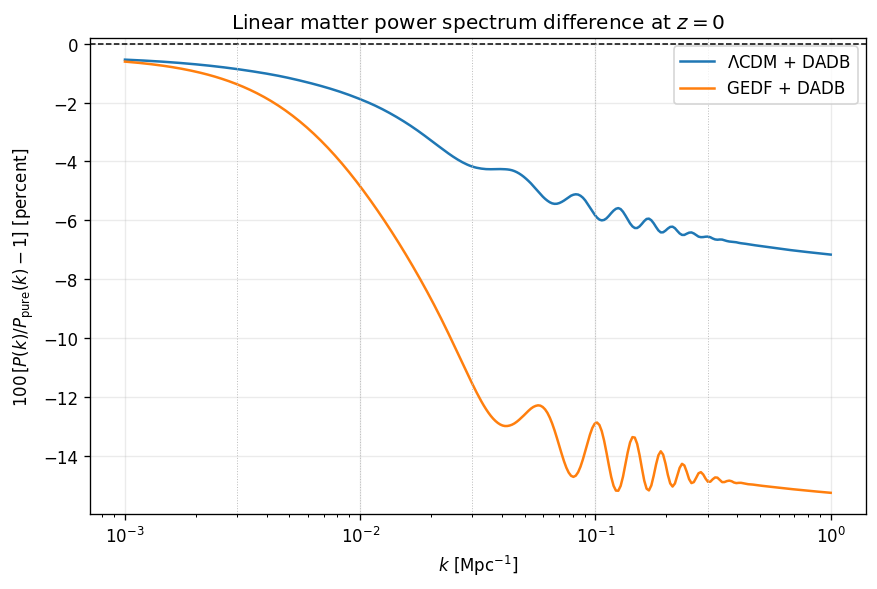

In [18]:
k_pk = np.geomspace(1e-3, 1.0, 300)  # 1/Mpc
pk_pure = np.array([pure_lcdm.pk(k, 0.0) for k in k_pk])
pk_lcdm_dadb = np.array([lcdm_dadb.pk(k, 0.0) for k in k_pk])
pk_gedf_dadb = np.array([gedf_dadb.pk(k, 0.0) for k in k_pk])

fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
ax.semilogx(k_pk, 100.0 * (pk_lcdm_dadb / pk_pure - 1.0), label=r'$\Lambda$CDM + DADB')
ax.semilogx(k_pk, 100.0 * (pk_gedf_dadb / pk_pure - 1.0), label='GEDF + DADB')
ax.axhline(0.0, color='k', lw=0.9, ls='--')
for k in K_MODES:
    ax.axvline(k, color='0.75', lw=0.6, ls=':')
ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$100\,[P(k)/P_{\mathrm{pure}}(k)-1]$ [percent]')
ax.set_title(r'Linear matter power spectrum difference at $z=0$')
ax.legend()
plt.show()

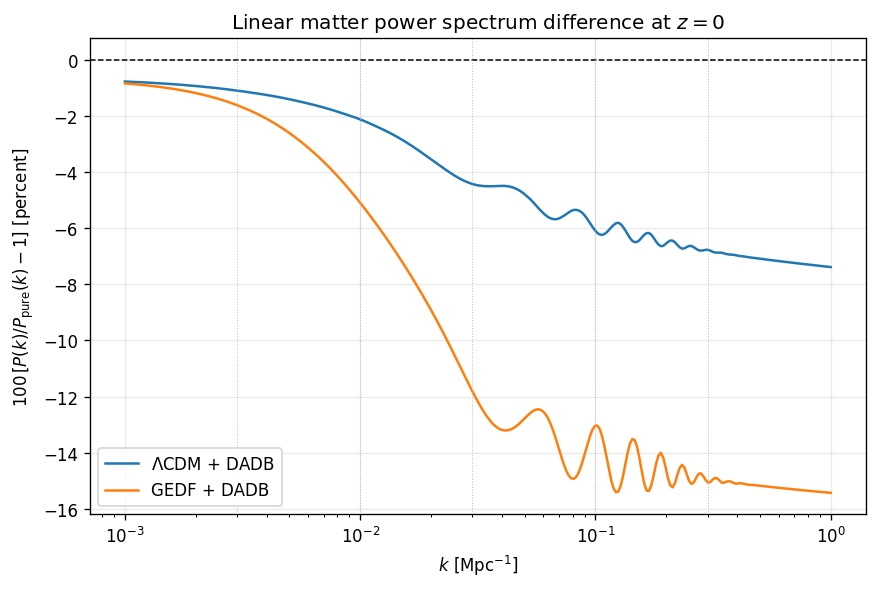

In [8]:
k_pk = np.geomspace(1e-3, 1.0, 300)  # 1/Mpc
pk_pure = np.array([pure_lcdm.pk(k, 0.0) for k in k_pk])
pk_lcdm_dadb = np.array([lcdm_dadb.pk(k, 0.0) for k in k_pk])
pk_gedf_dadb = np.array([gedf_dadb.pk(k, 0.0) for k in k_pk])

fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
ax.semilogx(k_pk, 100.0 * (pk_lcdm_dadb / pk_pure - 1.0), label=r'$\Lambda$CDM + DADB')
ax.semilogx(k_pk, 100.0 * (pk_gedf_dadb / pk_pure - 1.0), label='GEDF + DADB')
ax.axhline(0.0, color='k', lw=0.9, ls='--')
for k in K_MODES:
    ax.axvline(k, color='0.75', lw=0.6, ls=':')
ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$100\,[P(k)/P_{\mathrm{pure}}(k)-1]$ [percent]')
ax.set_title(r'Linear matter power spectrum difference at $z=0$')
ax.legend()
plt.show()

## Numerical summary and checks

In [7]:
assert np.all(np.isfinite(relative_lcdm_dadb))
assert np.all(np.isfinite(relative_gedf_dadb))
assert np.all(np.isfinite(pk_lcdm_dadb / pk_pure))
assert np.all(np.isfinite(pk_gedf_dadb / pk_pure))

print('z=0 total-CDM density-contrast differences:')
print(' k [1/Mpc]    LCDM+DADB [%]    GEDF+DADB [%]')
for i, k in enumerate(K_MODES):
    print(f' {k:8.3g}    {100*relative_lcdm_dadb[i,-1]:13.6f}    {100*relative_gedf_dadb[i,-1]:13.6f}')

print('\nz=0 linear power-spectrum differences at requested modes:')
print(' k [1/Mpc]    LCDM+DADB [%]    GEDF+DADB [%]')
for k in K_MODES:
    p0 = pure_lcdm.pk(k, 0.0)
    r1 = 100.0 * (lcdm_dadb.pk(k, 0.0) / p0 - 1.0)
    r2 = 100.0 * (gedf_dadb.pk(k, 0.0) / p0 - 1.0)
    print(f' {k:8.3g}    {r1:13.6f}    {r2:13.6f}')

print('\nAll finiteness checks passed.')

z=0 total-CDM density-contrast differences:
 k [1/Mpc]    LCDM+DADB [%]    GEDF+DADB [%]
    0.003        -0.552684        -0.814951
     0.01        -1.069047        -2.583088
     0.03        -2.236549        -6.088723
      0.1        -3.095528        -6.746963
      0.3        -3.442486        -7.834809

z=0 linear power-spectrum differences at requested modes:
 k [1/Mpc]    LCDM+DADB [%]    GEDF+DADB [%]
    0.003        -1.102463        -1.623195
     0.01        -2.128185        -5.099077
     0.03        -4.429242       -11.817694
      0.1        -6.101325       -13.032972
      0.3        -6.770097       -15.060551

All finiteness checks passed.


### Interpretation note

The first comparison isolates the late-time DADB background and drag effects relative to pure $\Lambda$CDM. The second contains both the early GEDF modification and late DADB effects, so it should not be interpreted as a DADB-only difference. These are synchronous-gauge density contrasts; while the requested same-gauge comparison is well defined, the individual large-scale density contrasts are gauge dependent.